In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

## Load data

In [3]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


### Train-test Split

In [ ]:
X = df.drop(columns=['malnurished'])
y = df['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

# Random Forest

### Simple model

In [4]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [5]:
y_pred = rf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.73      0.72       707
           1       0.66      0.64      0.65       579

    accuracy                           0.69      1286
   macro avg       0.68      0.68      0.68      1286
weighted avg       0.69      0.69      0.69      1286



### Average Precision Score

In [6]:
y_probas = rf.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.7405556881537553


# Hyperparameter Tuning

In [ ]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced'],
    'criterion': ['gini', 'entropy']
}

rf_params = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_params,
    param_grid=params,
    scoring='recall',     
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 192 candidates, totalling 960 fits


In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Recall:", grid_search.best_score_)

Best Parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Recall: 0.748266552468906


In [ ]:
rf_tune = grid_search.best_estimator_
y_pred = rf_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.59      0.67       707
           1       0.61      0.77      0.68       579

    accuracy                           0.67      1286
   macro avg       0.69      0.68      0.67      1286
weighted avg       0.69      0.67      0.67      1286



## Average precision

In [ ]:
y_probas_tune = rf_tune.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas_tune)}')

Average Precision: 0.7148401263655063


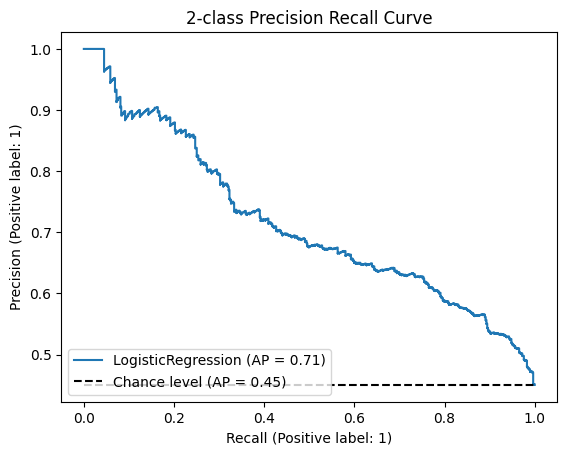

In [ ]:
display = PrecisionRecallDisplay.from_estimator(
    rf_tune,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

### Confusion matrix

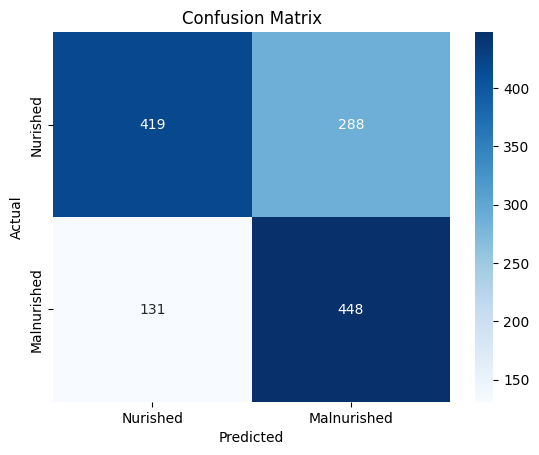

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Feature importance

In [ ]:
# Get feature importances
importances = rf_tune.feature_importances_
feature_names = X_train.columns

# Create a DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Importance (abs)': np.abs(importances)
}).sort_values(by='Importance', ascending=False)

# Display
print(importance_df)

                   Feature  Importance  Importance (abs)
1             child_weight    0.490854          0.490854
0                child_age    0.155176          0.155176
6         mother_education    0.085443          0.085443
8             wealth_index    0.077188          0.077188
11            province_3.0    0.056566          0.056566
14            province_6.0    0.028147          0.028147
4                     area    0.016721          0.016721
12            province_4.0    0.015863          0.015863
9             province_1.0    0.012391          0.012391
15            province_7.0    0.012063          0.012063
10            province_2.0    0.011102          0.011102
7         health_insurance    0.010422          0.010422
2   diarrhoea_last_2_weeks    0.008252          0.008252
5                child_sex    0.007860          0.007860
3       fever_last_2_weeks    0.006752          0.006752
13            province_5.0    0.005199          0.005199


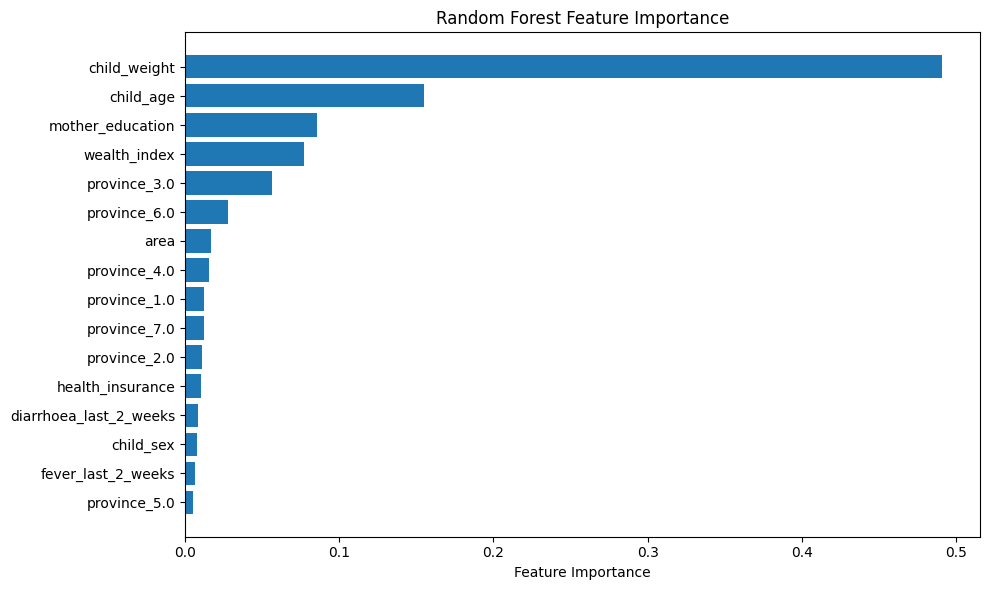

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Additional

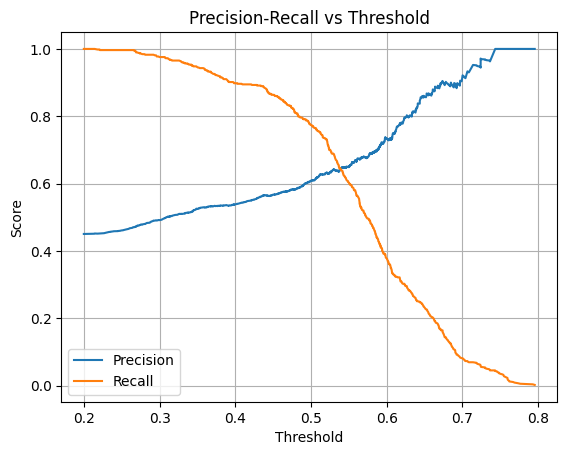

In [ ]:
y_probas = rf_tune.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [ ]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.82      0.37      0.51       707
           1       0.54      0.90      0.67       579

    accuracy                           0.61      1286
   macro avg       0.68      0.63      0.59      1286
weighted avg       0.69      0.61      0.58      1286


